# Elementary Cellular Automata

> Note: This is a slightly edited reposting of [an article I originally published on the Matplotlib Blog](https://matplotlib.org/matplotblog/posts/elementary-cellular-automata/)

![cone snail](../assets/images/CA_cone_snail.jpeg)

[Cellular automata](https://en.wikipedia.org/wiki/Cellular_automaton)
are discrete models, typically on a grid, which evolve in time. Each
grid cell has a finite state, such as 0 or 1, which is updated based on
a certain set of rules. A specific cell uses information of the
surrounding cells, called its *neighborhood*, to determine what changes
should be made. In general cellular automata can be defined in any
number of dimensions. A famous two dimensional example is [Conway’s Game
of Life](https://en.wikipedia.org/wiki/Conway%27s_Game_of_Life) in which
cells “live” and “die”, sometimes producing beautiful patterns.

In this post we will be looking at a one dimensional example known as
[elementary cellular
automaton](https://en.wikipedia.org/wiki/Elementary_cellular_automaton),
popularized by [Stephen
Wolfram](https://en.wikipedia.org/wiki/Stephen_Wolfram) in the 1980s.

![](../assets/images/CA_strip.png)

Imagine a row of cells, arranged side by side, each of which is colored
black or white. We label black cells 1 and white cells 0, resulting in
an array of bits. As an example let's consider a random array of 20 bits.

In [ ]:
import numpy as np

rng = np.random.default_rng(35)
data = rng.integers(0, 2, 20)

print(data)

[0 0 1 0 1 1 0 1 0 0 1 0 0 0 0 1 0 1 1 1]


To update the state of our cellular automaton we will need to define a
set of rules. A given cell $C$ only knows about the state of its left
and right neighbors, labeled $L$ and $R$ respectively. We can define
a function or rule, $f(L, C, R)$, which maps the cell state to either
0 or 1.

Since our input cells are binary values there are $2^3=8$ possible
inputs into the function.

In [ ]:
for i in range(8):
    print(np.binary_repr(i, 3))

000
001
010
011
100
101
110
111


For each input triplet, we can assign 0 or 1 to the output. The output
of $f$ replaces the current value of $C$ in the
next time step. In total there are $2^{2^3} = 2^8 = 256$
possible rules for updating a cell. Stephen Wolfram introduced a naming
convention, now known as the [Wolfram
Code](https://en.wikipedia.org/wiki/Wolfram_code), for the update rules
in which each rule is represented by an 8 bit binary number.

For example "Rule 30" could be constructed by first converting to binary
and then building an array for each bit

In [ ]:
rule_number = 30
rule_string = np.binary_repr(rule_number, 8)
rule = np.array([int(bit) for bit in rule_string])
print(rule)

[0 0 0 1 1 1 1 0]


By convention the Wolfram code associates the leading bit with '111' and
the final bit with '000'. For rule 30 the relationship between the
input, rule index and output is as follows:

In [ ]:
for i in range(8):
    triplet = np.binary_repr(i, 3)
    print(f"input:{triplet}, index:{7-i}, output {rule[7-i]}")

input:000, index:7, output 0
input:001, index:6, output 1
input:010, index:5, output 1
input:011, index:4, output 1
input:100, index:3, output 1
input:101, index:2, output 0
input:110, index:1, output 0
input:111, index:0, output 0


We can define a function which maps each input triplet to the appropriate rule index. Essentially we are converting the binary input to
decimal and adjusting the index range.

In [ ]:
def rule_index(triplet):
    L, C, R = triplet
    index = 7 - (4*L + 2*C + R)
    return int(index)

Now we can take in any input and look up the output based on our rule,
for example:

In [ ]:
print(rule[rule_index((1, 0, 1))])

0


Instead of looping over all triplets and applying the `rule_index` function for each, we can adopt a vectorized approach. The neighbors are constructed by offsetting the array and the rule indicies are calculated all at once. By using `np.roll` we treat the array as circular, so the left edge wraps around to the right edge and vice versa.

In [ ]:
L = np.roll(data, 1)
C = data
R = np.roll(data, -1)
indices = 7 - (4*L + 2*C + R)
new_data = rule[indices]
print(new_data)

[1 1 1 0 1 0 0 1 1 1 1 1 0 0 1 1 0 1 0 0]


That is the process for a single update of our cellular automata.

To do many updates and record the state over time, we will create a
function.

In [ ]:
def CA_run(initial_state, n_steps, rule_number):
    rule_string = np.binary_repr(rule_number, 8)
    rule = np.array([int(bit) for bit in rule_string])

    m_cells = len(initial_state)
    CA_run = np.zeros((n_steps, m_cells), dtype=int)
    CA_run[0, :] = initial_state

    for step in range(1, n_steps):
        
        L = np.roll(CA_run[step - 1], 1)
        C = CA_run[step - 1]
        R = np.roll(CA_run[step - 1], -1)

        indices = 7 - (4*L + 2*C + R)
        
        CA_run[step] = rule[indices]
        
    return CA_run

In [ ]:
initial = np.array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0])
data = CA_run(initial, 10, 30)
print(data)

[[0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0]
 [1 1 1 0 1 1 1 0 1 1 1 0 0 1 1 0 1 0 0 1]
 [0 0 0 0 1 0 0 0 1 0 0 1 1 1 0 0 1 1 1 1]
 [1 0 0 1 1 1 0 1 1 1 1 1 0 0 1 1 1 0 0 0]
 [1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1]
 [0 0 0 0 1 0 1 1 1 0 0 1 1 0 0 1 1 1 0 1]
 [1 0 0 1 1 0 1 0 0 1 1 1 0 1 1 1 0 0 0 1]
 [0 1 1 1 0 0 1 1 1 1 0 0 0 1 0 0 1 0 1 1]
 [0 1 0 0 1 1 1 0 0 0 1 0 1 1 1 1 1 0 1 0]
 [1 1 1 1 1 0 0 1 0 1 1 0 1 0 0 0 0 0 1 1]]


## Let’s Get Visual

For larger simulations, interesting patterns start to emerge. To
visualize our simulation results we will use the `ax.matshow` function.

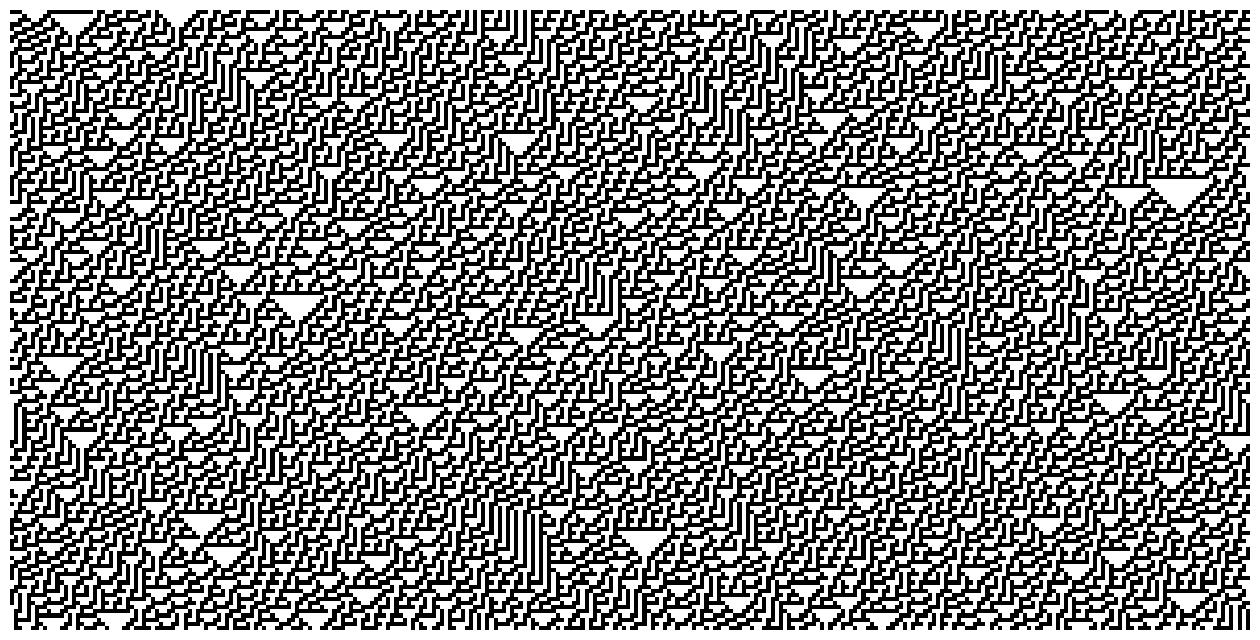

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'binary'

rng = np.random.default_rng(0)
data = CA_run(rng.integers(0, 2, 300), 150, 30)

fig, ax = plt.subplots(figsize=(16, 9))
ax.matshow(data)
ax.axis(False);

## Learning the Rules

With the code set up to produce the simulation, we can now start to
explore the properties of these different rules. Wolfram separated the
rules into four classes which are outlined below.

In [ ]:
def plot_CA_class(rule_list, class_label):
    rng = np.random.default_rng(0)
    fig, axs = plt.subplots(1, len(rule_list),figsize=(10, 3.5), constrained_layout=True)
    initial = rng.integers(0, 2, 100)

    for i, ax in enumerate(axs.ravel()):
        data = CA_run(initial, 100, rule_list[i])
        ax.set_title(f'Rule {rule_list[i]}')
        ax.matshow(data)
        ax.axis(False)

    fig.suptitle(class_label, fontsize=16)

    return fig, ax

### Class One

Cellular automata which rapidly converge to a uniform state

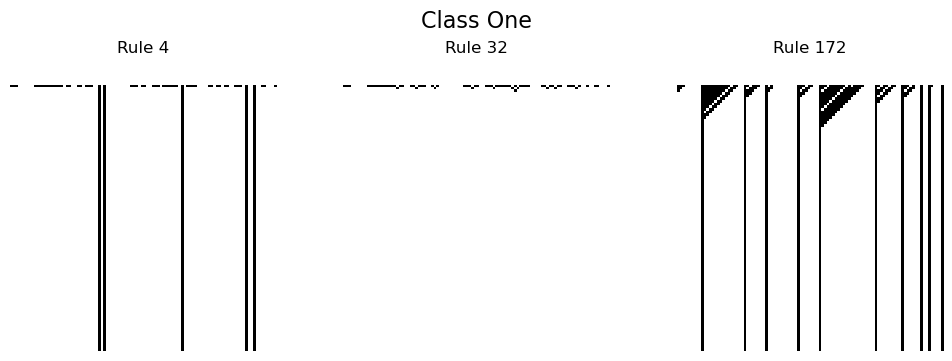

In [ ]:
_ = plot_CA_class([4, 32, 172], 'Class One')

### Class Two

Cellular automata which rapidly converge to a repetitive or stable state

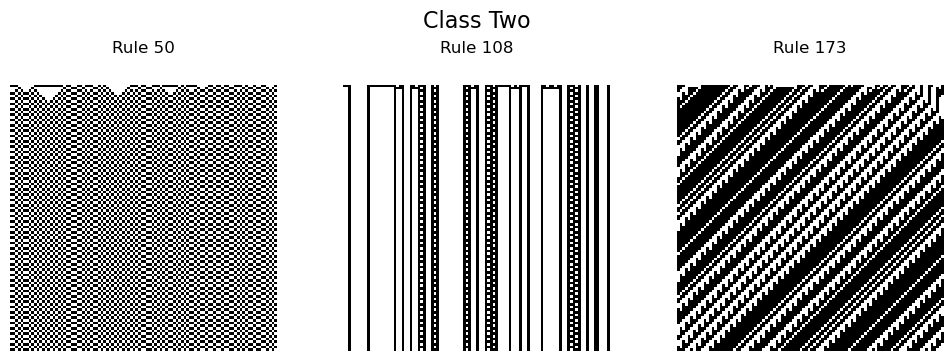

In [ ]:
_ = plot_CA_class([50, 108, 173], 'Class Two')

### Class Three

Cellular automata which appear to remain in a random state

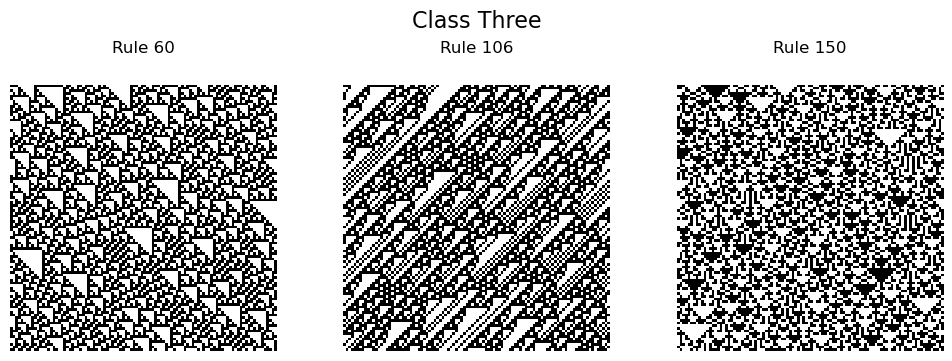

In [ ]:
_ = plot_CA_class([60, 106, 150], 'Class Three')

### Class Four

Cellular automata which form areas of repetitive or stable states, but
also form structures that interact with each other in complicated ways.

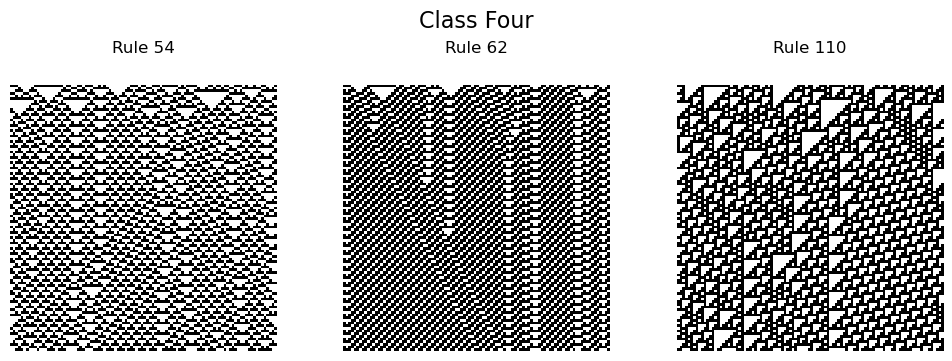

In [ ]:
_ = plot_CA_class([54, 62, 110], 'Class Four')

Amazingly, the interacting structures which emerge from rule 110 has
been shown to be capable of [universal
computation](https://en.wikipedia.org/wiki/Turing_machine).

In all the examples above a random initial state was used, but another
interesting case is when a single 1 is initialized with all other values
set to zero.

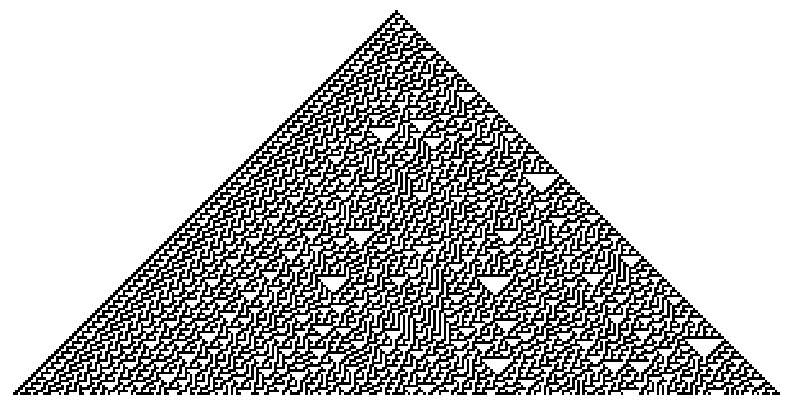

In [ ]:
initial = np.zeros(300)
initial[300//2] = 1
data = CA_run(initial, 150, 30)

fig, ax = plt.subplots(figsize=(10, 5))
ax.matshow(data)
ax.axis(False);

For certain rules, the emergent structures interact in chaotic and
interesting ways.

I hope you enjoyed this brief look into the world of elementary cellular
automata, and are inspired to make some pretty pictures of your own.